# **Анализ влияния места работы на показатели гемоглобина (ANOVA)**

## **1. Введение**

### Описание проекта

Данное исследование посвящено анализу эффективности реабилитационных мероприятий для сотрудников промышленных предприятий. В качестве ключевого биомаркера восстановительного процесса рассматривается **уровень гемоглобина (Hb)**. В рамках проекта исследуется вопрос о том, оказывают ли специфические условия производственной среды на различных площадках системное влияние на результаты лечения при применении единых медицинских протоколов.

### Цель исследования

Статистическая верификация наличия или отсутствия значимых различий в уровне гемоглобина у сотрудников **трех независимых предприятий** на момент завершения реабилитации. Целью является математическое обоснование однородности терапевтического эффекта или выявление необходимости дифференциации подходов к лечению в зависимости от места работы.

### Стек технологий и компетенции

Для реализации аналитического цикла применен специализированный стек инструментов на языке Python:

* **Pandas / Numpy** — структурирование данных, очистка выборок от пропусков, расчет дескриптивных метрик.
* **Scipy.stats** — проверка математических допущений: тест Шапиро-Уилка на нормальность и тест Левена на гомогенность дисперсий.
* **Statsmodels** — проведение однофакторного дисперсионного анализа (ANOVA) и апостериорного сравнения методом Тьюки (Tukey HSD).
* **Seaborn / Matplotlib** — построение экспертной графики (Q-Q plots, Violin plots, Point plots с доверительными интервалами и матрицы значимости).

---

### Структура анализа

1. **Проверка статистических допущений:** Анализ распределений и равенства дисперсий для обоснования выбора параметрических методов.
2. **Дескриптивный анализ:** Расчет центральных тенденций и показателей вариативности для каждой производственной площадки.
3. **Дисперсионный анализ (ANOVA):** Глобальная проверка гипотезы о влиянии фактора «Предприятие» на целевой показатель.
4. **Post-hoc анализ (Тест Тьюки):** Локализация значимых различий между конкретными парами предприятий.
5. **Интерпретация и выводы:** Синтез статистических данных и визуализаций для формирования итогового заключения.

In [ ]:
from google.colab import files
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [ ]:
files.upload()
df = pd.read_excel('task1.xlsx', index_col=0)
df

Saving task1.xlsx to task1 (3).xlsx


,Hb1Bef,Hb1Aft,Hb2Bef,Hb2Aft,Hb3Bef,Hb3Aft
0,136,126,114,121,136,127
1,114,138,128,137,136,105
2,115,124,131,122,113,134
3,109,150,139,127,126,126
4,129,117,123,117,127,114
...,...,...,...,...,...,...
195,104,138,142,120,127,127
196,126,111,134,143,105,123
197,124,139,137,125,127,115
198,128,130,122,139,132,137


## **2. Предварительный обзор и визуальный анализ данных**

На данном этапе проводится первичный осмотр данных, рассчитываются ключевые показатели центральной тенденции и оценивается форма распределения исследуемого признака для каждой группы.

### 2.1. Расчет описательных статистик

Для первичной оценки подготовлена сводная таблица, включающая средние значения, медианы и показатели разброса уровня гемоглобина (Hb) для рабочих трех предприятий (суммарная выборка $N=600$).

In [ ]:
# 2. Выборка данных для анализа (уровень гемоглобина на момент выписки)
hb1 = df['Hb1Aft'].dropna()
hb2 = df['Hb2Aft'].dropna()
hb3 = df['Hb3Aft'].dropna()

# 3. Формулировка гипотез
print("Статистические гипотезы:")
print("H0: Средние уровни гемоглобина на трех предприятиях равны (m1 = m2 = m3)")
print("H1: Как минимум два средних значения значимо различаются")
print("-" * 30)

# 4. Расчет описательных статистик
stats = pd.DataFrame({
    'Предприятие 1': hb1.describe(),
    'Предприятие 2': hb2.describe(),
    'Предприятие 3': hb3.describe()
})

print("Описательные статистики (Гемоглобин при выписке):")
stats.round(2)

Статистические гипотезы:
H0: Средние уровни гемоглобина на трех предприятиях равны (m1 = m2 = m3)
H1: Как минимум два средних значения значимо различаются
------------------------------
Описательные статистики (Гемоглобин при выписке):


,Предприятие 1,Предприятие 2,Предприятие 3
count,200.00,200.00,200.00
mean,129.96,131.20,128.62
std,10.37,9.94,10.05
min,102.00,104.00,104.00
25%,123.00,125.00,122.00
50%,129.00,132.00,128.50
75%,137.00,139.00,135.00
max,160.00,165.00,155.00


**Проверка соответствия целевым медицинским показателям**


На данном этапе анализируется не только разница между группами, но и их соответствие внешнему критерию качества. В качестве контрольного значения выбран уровень 130 гр/л — нижняя граница нормы гемоглобина.

**Постановка задачи**


Необходимо статистически подтвердить, достигают ли сотрудники Предприятий №2 и №3 целевого показателя после завершения лечения. Для этого применяется одновыборочный t-критерий Стьюдента с односторонней альтернативной гипотезой (проверка на снижение).

Для решения данной задачи необходимо провести **односторонний t-тест для одной выборки** (One-sample t-test). Мы сравниваем средние значения каждой группы с константой (норма в 130 гр/л).

**1. Формулировка гипотез**


* **Нулевая гипотеза ($H_0$):** Средний уровень гемоглобина равен или выше 130 гр/л (норма).
* **Альтернативная гипотеза ($H_1$):** Средний уровень гемоглобина статистически значимо ниже 130 гр/л (снижен).

,Предприятие,Среднее (Mean),t-статистика,p-value,Стат. вывод
0,Предприятие 2,131.195,1.6994,0.9546,Соответствует норме
1,Предприятие 3,128.620,-1.9412,0.0268,Уровень значимо снижен


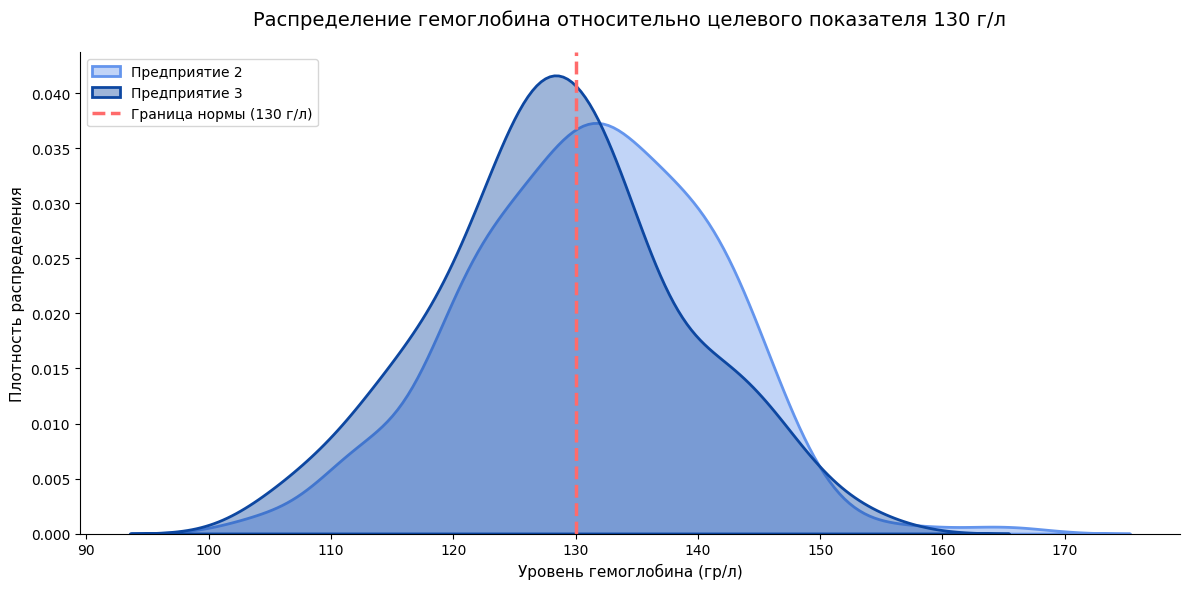

In [ ]:
norm_value = 130

target_data = {
    'Предприятие 2': df['Hb2Aft'].dropna(),
    'Предприятие 3': df['Hb3Aft'].dropna()
}

# Реализация одностороннего t-теста
test_results = []
for name, data in target_data.items():
    # Нулевая гипотеза (H0): Среднее >= 130
    # Альтернативная гипотеза (H1): Среднее < 130 (alternative='less')
    t_stat, p_val = stats.ttest_1samp(data, norm_value, alternative='less')

    test_results.append({
        'Предприятие': name,
        'Среднее (Mean)': data.mean(),
        't-статистика': t_stat,
        'p-value': p_val,
        'Стат. вывод': 'Уровень значимо снижен' if p_val < 0.05 else 'Соответствует норме'
    })

df_norm_check = pd.DataFrame(test_results)
display(df_norm_check.round(4))

plt.figure(figsize=(12, 6), facecolor='white')
colors = ['#6495ED', '#0D47A1']

for i, (name, data) in enumerate(target_data.items()):
    sns.kdeplot(data, fill=True, label=name, color=colors[i], alpha=0.4, linewidth=2)

plt.axvline(norm_value, color='#FF6B6B', linestyle='--', linewidth=2.5, label=f'Граница нормы ({norm_value} г/л)')

plt.title('Распределение гемоглобина относительно целевого показателя 130 г/л', fontsize=14, pad=20)
plt.xlabel('Уровень гемоглобина (гр/л)', fontsize=11)
plt.ylabel('Плотность распределения', fontsize=11)
plt.legend(frameon=True, loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

**На основании проведенного тестирования сделаны следующие заключения:**

* Предприятие 2: Средний показатель (131.20 гр/л) находится выше критической отметки. Значение  p=0.955  подтверждает, что в данной группе отсутствует статистически значимое снижение уровня гемоглобина относительно стандарта. Процесс реабилитации признан эффективным.
* Предприятие 3: Средний показатель (128.62 гр/л) достоверно ниже нормы. Полученное значение  p=0.027  (ниже уровня значимости  0.05 ) позволяет отклонить нулевую гипотезу. У сотрудников данного предприятия зафиксирован статистически значимый дефицит гемоглобина.



Несмотря на то, что сотрудники обоих предприятий проходили лечение по схожим протоколам, на Предприятии 3 выявлена системная проблема — средний показатель гемоглобина по группе не достигает целевого значения в 130 гр/л. Это указывает на необходимость аудита условий труда или пересмотра программ медицинского обеспечения на конкретной производственной площадке.

---
**Сравнительный анализ состояния групп на момент госпитализации**

Для объективной оценки эффективности последующего лечения необходимо установить, существовали ли значимые различия в уровне гемоглобина между сотрудниками предприятий №2 и №3 на начальном этапе (при поступлении в стационар).

**Постановка статистической задачи**

Сравниваются две независимые выборки. Проверяется гипотеза о равенстве средних значений гемоглобина на момент госпитализации (`Hb2Bef` и `Hb3Bef`).

* **Нулевая гипотеза ($H_0$):** Средние уровни гемоглобина на предприятиях №2 и №3 при госпитализации равны.
* **Альтернативная гипотеза ($H_1$):** Существует статистически значимое различие в исходном состоянии рабочих двух предприятий.

Описательные статистики на момент госпитализации:


,Метрика,Предприятие 2,Предприятие 3
0,Размер выборки (n),200.00,200.00
1,Среднее Hb (Bef),127.98,128.74
2,Станд. отклонение,10.45,9.11



Результаты t-теста:


,Параметр,Значение
0,t-статистика,-0.7751
1,p-value,0.4388
2,Результат,Различия не обнаружены


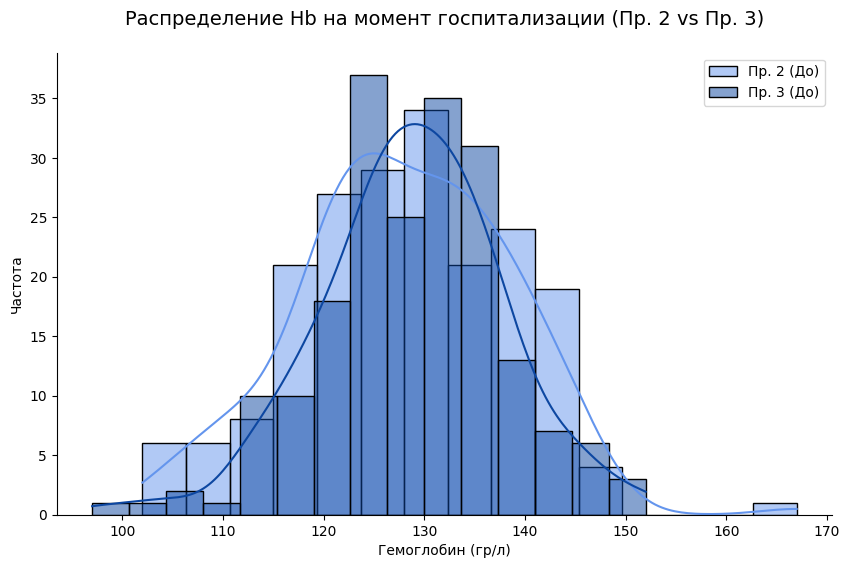

In [ ]:
bef2 = df['Hb2Bef'].dropna()
bef3 = df['Hb3Bef'].dropna()

# 2. Проведение двухвыборочного t-теста (независимые выборки)
t_stat, p_val = stats.ttest_ind(bef2, bef3)

init_comparison = pd.DataFrame({
    'Метрика': ['Размер выборки (n)', 'Среднее Hb (Bef)', 'Станд. отклонение'],
    'Предприятие 2': [len(bef2), bef2.mean(), bef2.std()],
    'Предприятие 3': [len(bef3), bef3.mean(), bef3.std()]
})

test_summary = pd.DataFrame({
    'Параметр': ['t-статистика', 'p-value', 'Результат'],
    'Значение': [round(t_stat, 4), round(p_val, 4),
                 'Различия значимы' if p_val < 0.05 else 'Различия не обнаружены']
})

print("Описательные статистики на момент госпитализации:")
display(init_comparison.round(2))
print("\nРезультаты t-теста:")
display(test_summary)

plt.figure(figsize=(10, 6), facecolor='white')
custom_palette = ["#6495ED", "#0D47A1"]

sns.histplot(bef2, color=custom_palette[0], kde=True, label='Пр. 2 (До)', alpha=0.5, bins=15)
sns.histplot(bef3, color=custom_palette[1], kde=True, label='Пр. 3 (До)', alpha=0.5, bins=15)

plt.title('Распределение Hb на момент госпитализации (Пр. 2 vs Пр. 3)', fontsize=14, pad=20)
plt.xlabel('Гемоглобин (гр/л)')
plt.ylabel('Частота')
plt.legend()
sns.despine()
plt.show()

**Анализ исходного состояния групп на момент госпитализации**

Для обеспечения чистоты эксперимента и исключения влияния исходного состояния здоровья на конечные результаты реабилитации, было проведено сравнение уровней гемоглобина у сотрудников Предприятий №2 и №3 непосредственно при поступлении в стационар.

**Результаты статистического анализа:**

* **Сравнительные показатели:** На момент госпитализации средний уровень гемоглобина у рабочих Предприятия №2 составил **127.98 гр/л**, а у рабочих Предприятия №3 — **128.74 гр/л**. Разница между средними значениями составила менее **1 гр/л**.
* **Статистическая значимость:** Применение t-критерия Стьюдента для независимых выборок показало значение $p = 0.4388$. Поскольку полученный показатель значительно превышает критический уровень значимости $\alpha = 0.05$, нулевая гипотеза о равенстве средних не отклоняется.
* **Вариативность:** Показатели стандартного отклонения в обеих группах сопоставимы (**10.45** и **9.11** соответственно), что подтверждает однородность выборок по степени разброса признака в начале исследования.




Статистический анализ подтвердил, что на момент начала лечения сотрудники обоих предприятий находились в **идентичном состоянии** по уровню гемоглобина. Выявленные ранее различия, зафиксированные на момент выписки, не связаны с исходным фоном здоровья пациентов, а обусловлены факторами, возникшими в процессе лечения или спецификой производственной среды предприятий.

---

**Оценка клинической эффективности лечения (парный анализ)**

Критически важным аспектом исследования является проверка того, произошло ли статистически значимое улучшение состояния рабочих внутри каждой группы в процессе терапии.

**Постановка задачи**


Проводится сравнение двух зависимых выборок (показатели при госпитализации и при выписки) для каждого предприятия отдельно.

* **Нулевая гипотеза ($H_0$):** Средний уровень гемоглобина до и после лечения совпадает; терапия не оказала значимого влияния.
* **Альтернативная гипотеза ($H_1$):** Существует статистически значимая разница между показателями (положительный сдвиг).


,Объект,Среднее ДО,Среднее ПОСЛЕ,Динамика (Δ),t-статистика,p-value,Эффект
0,Предприятие 2,127.985,131.195,3.210,-3.3041,0.0011,Значим
1,Предприятие 3,128.745,128.620,-0.125,0.1262,0.8997,Незначим


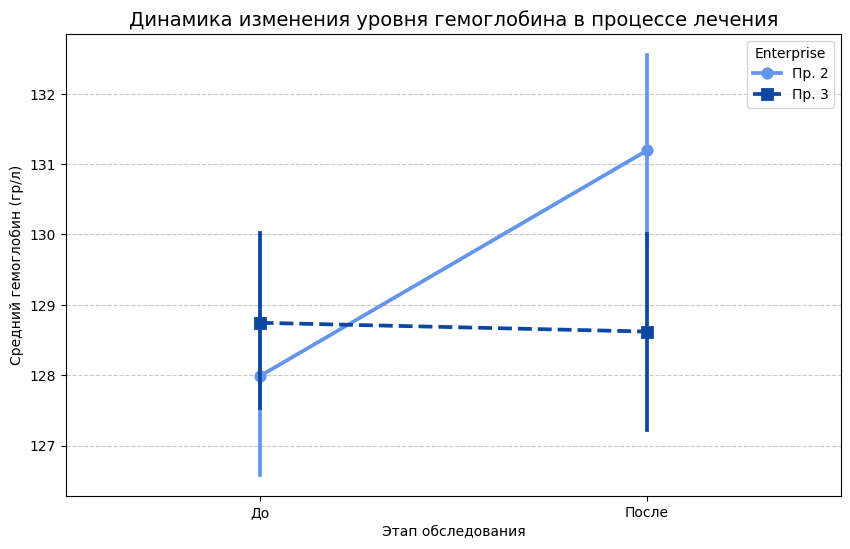

In [ ]:
groups_to_test = {
    'Предприятие 2': (df['Hb2Bef'].dropna(), df['Hb2Aft'].dropna()),
    'Предприятие 3': (df['Hb3Bef'].dropna(), df['Hb3Aft'].dropna())
}

paired_results = []

for name, (bef, aft) in groups_to_test.items():
    t_stat, p_val = stats.ttest_rel(bef, aft)

    paired_results.append({
        'Объект': name,
        'Среднее ДО': bef.mean(),
        'Среднее ПОСЛЕ': aft.mean(),
        'Динамика (Δ)': aft.mean() - bef.mean(),
        't-статистика': t_stat,
        'p-value': p_val,
        'Эффект': 'Значим' if p_val < 0.05 else 'Незначим'
    })

df_paired = pd.DataFrame(paired_results)
display(df_paired.round(4))

plt.figure(figsize=(10, 6))
plot_data = pd.melt(df[['Hb2Bef', 'Hb2Aft', 'Hb3Bef', 'Hb3Aft']],
                    value_vars=['Hb2Bef', 'Hb2Aft', 'Hb3Bef', 'Hb3Aft'],
                    var_name='Stage', value_name='Hb')

plot_data['Enterprise'] = plot_data['Stage'].apply(lambda x: 'Пр. 2' if '2' in x else 'Пр. 3')
plot_data['Time'] = plot_data['Stage'].apply(lambda x: 'До' if 'Bef' in x else 'После')

sns.pointplot(data=plot_data, x='Time', y='Hb', hue='Enterprise',
              palette=['#6495ED', '#0D47A1'], markers=["o", "s"], linestyles=["-", "--"])

plt.title('Динамика изменения уровня гемоглобина в процессе лечения', fontsize=14)
plt.ylabel('Средний гемоглобин (гр/л)')
plt.xlabel('Этап обследования')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Сравнительный анализ эффективности терапии внутри групп**

Для оценки результативности проведенного лечения был выполнен парный анализ показателей гемоглобина (до и после терапии) для каждого предприятия. Использование **парного t-критерия Стьюдента** позволило определить наличие и статистическую достоверность динамики внутри каждой выборки.

*Результаты внутригруппового анализа:*

* **Предприятие №2 (Положительная динамика):** У сотрудников данной группы зафиксирован статистически значимый прирост уровня гемоглобина. Среднее значение увеличилось со **127.99 гр/л** до **131.20 гр/л** (чистая динамика $\Delta = +3.21$). Полученное значение $p = 0.0011$ (ниже порога 0.05) подтверждает высокую эффективность реабилитационных мероприятий на данной площадке.
* **Предприятие №3 (Отсутствие эффекта):** В данной группе положительных изменений не выявлено. Средний уровень гемоглобина практически не изменился, продемонстрировав незначительное отрицательное колебание на **-0.125 гр/л** ($p = 0.8997$). Столь высокое значение $p$-value указывает на то, что состояние рабочих осталось на исходном уровне, а терапия не оказала значимого влияния на ключевой показатель.




Проведенный парный тест выявил критическую проблему в процессе восстановления сотрудников Предприятия №3. В то время как на Предприятии №2 наблюдается уверенный и статистически подтвержденный прогресс, сотрудники Предприятия №3 демонстрируют **стагнацию показателей**.

С учетом того, что исходное состояние групп (см. раздел 6) было идентичным, а протоколы лечения — схожими, можно сделать вывод о наличии специфических внешних факторов на Предприятии №3 (экологические условия, производственная среда или образ жизни), которые препятствуют эффективному восстановлению организма и нейтрализуют результаты медицинской терапии.

---

### 2.2. Визуальный анализ распределений

Для глубокого понимания структуры данных используется комбинированный метод визуализации: диаграмма размаха (**Boxplot**) для выявления диапазона значений и потенциальных выбросов, а также график плотности (**KDE**) для оценки симметрии и унимодальности распределений.

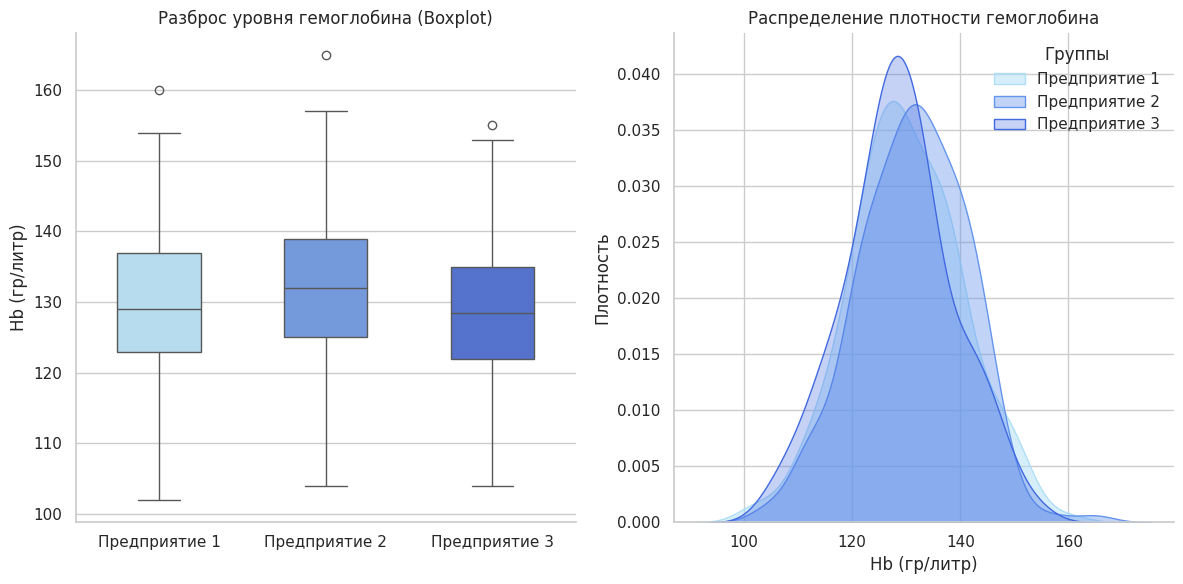

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
blue_palette = ["#AEDFF7", "#6495ED", "#4169E1"]

# 1. Создаем Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=[hb1, hb2, hb3], palette=blue_palette, width=0.5)
plt.xticks([0, 1, 2], ['Предприятие 1', 'Предприятие 2', 'Предприятие 3'])
plt.title('Разброс уровня гемоглобина (Boxplot)', fontsize=12)
plt.ylabel('Hb (гр/литр)')

# 2. Создаем график плотности (KDE Plot)
plt.subplot(1, 2, 2)
sns.kdeplot(hb1, fill=True, label='Предприятие 1', color=blue_palette[0], alpha=0.5)
sns.kdeplot(hb2, fill=True, label='Предприятие 2', color=blue_palette[1], alpha=0.4)
sns.kdeplot(hb3, fill=True, label='Предприятие 3', color=blue_palette[2], alpha=0.3)

plt.title('Распределение плотности гемоглобина', fontsize=12)
plt.xlabel('Hb (гр/литр)')
plt.ylabel('Плотность')
plt.legend(title="Группы")

sns.despine()
plt.tight_layout()
plt.show()

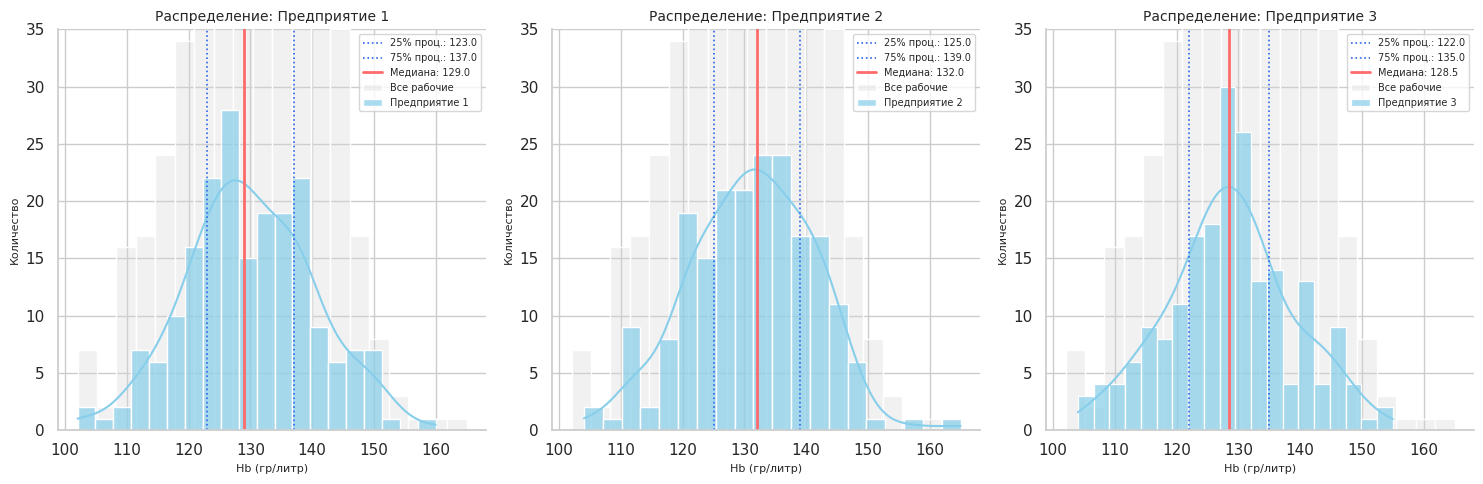

In [ ]:
all_hb = df[['Hb1Aft', 'Hb2Aft', 'Hb3Aft']].stack()
groups = [('Hb1Aft', 'Предприятие 1'), ('Hb2Aft', 'Предприятие 2'), ('Hb3Aft', 'Предприятие 3')]

plt.figure(figsize=(15, 5))

for i, (col, name) in enumerate(groups, 1):
    plt.subplot(1, 3, i)

    # Расчет статистик
    q1 = df[col].quantile(0.25)
    median = df[col].median()
    q3 = df[col].quantile(0.75)

    sns.histplot(all_hb, color='lightgrey', kde=False, bins=20, alpha=0.3, label='Все рабочие')
    sns.histplot(df[col], kde=True, bins=20, color='skyblue', edgecolor='white', alpha=0.7, label=name)

    # Линии процентилей
    plt.axvline(q1, color='#2B65EC', linestyle=':', linewidth=1.2, label=f'25% проц.: {q1:.1f}')
    plt.axvline(q3, color='#2B65EC', linestyle=':', linewidth=1.2, label=f'75% проц.: {q3:.1f}')

    # Линия медианы
    plt.axvline(median, color='#FF6B6B', linestyle='-', linewidth=2, label=f'Медиана: {median:.1f}')

    # Установка лимита оси Y на 35
    plt.ylim(0, 35)
    plt.title(f'Распределение: {name}', fontsize=10)
    plt.xlabel('Hb (гр/литр)', fontsize=8)
    plt.ylabel('Количество', fontsize=8)
    plt.legend(fontsize=7, loc='upper right', frameon=True, shadow=False)

sns.despine()
plt.tight_layout()
plt.show()

### 2.3. Формулировка статистических гипотез и интерпретация показателей

На основе поставленных задач исследования сформулированы следующие гипотезы:

* **Нулевая гипотеза ($H_0$):** Средние уровни гемоглобина у сотрудников всех трех предприятий идентичны; наблюдаемые различия носят случайный характер ($\mu_1 = \mu_2 = \mu_3$).
* **Альтернативная гипотеза ($H_1$):** Существует статистически значимое различие как минимум между двумя группами предприятий.

#### Анализ полученных статистических данных:

Предварительный расчет описательных статистик ($N=600$) позволяет сделать ряд промежуточных выводов:

* **Однородность выборок:** Группы полностью идентичны по объему ($n=200$), что обеспечивает высокую мощность последующих статистических критериев.
* **Вариативность признака:** Показатели стандартного отклонения ($\sigma$) находятся в узком диапазоне от **9.94** до **10.37**, что свидетельствует о схожем характере разброса данных во всех группах.
* **Сравнение средних значений:** Наивысший средний показатель гемоглобина зафиксирован на **Предприятии 2** ($131.20$ гр/л), в то время как минимальный — на **Предприятии 3** ($128.62$ гр/л).
* **Симметричность данных:** Близость значений среднего арифметического и медианы во всех трех выборках (например, $129.96$ vs $129.00$ для Пр. 1) указывает на отсутствие выраженной асимметрии распределения.

**Заключение по этапу:** Обнаруженные различия в средних значениях ($\Delta \approx 2.58$ гр/л) требуют дальнейшей проверки с помощью методов инференциальной статистики для исключения фактора случайности.

---

## **3. Проверка статистических допущений**

Перед применением параметрического метода однофакторного дисперсионного анализа (ANOVA) проводится верификация ключевых условий применимости. Это гарантирует надежность полученных p-значений и предотвращает ложноположительные выводы.

### 3.1. Оценка нормальности распределения

Для проверки соответствия эмпирических данных теоретическому нормальному распределению используется **тест Шапиро-Уилка**.

* **Нулевая гипотеза ($H_0$):** Данные распределены нормально.
* **Альтернативная гипотеза ($H_1$):** Распределение значимо отличается от нормального.
* **Критерий принятия решения:** Если $p > 0.05$, принимается гипотеза о нормальности распределения.

Дополнительно выполняется визуальный контроль с использованием графиков **Q-Q Plot (Quantile-Quantile Plot)**, позволяющих оценить отклонения в «хвостах» распределения.

### 3.2. Проверка гомогенности дисперсий

Для оценки равенства вариаций внутри групп применяется **тест Левена**. Данный этап критически важен, так как существенные различия в разбросе данных между предприятиями могут привести к смещению F-статистики.

* **Нулевая гипотеза ($H_0$):** Дисперсии в группах гомогенны (равны).
* **Критерий принятия решения:** При $p > 0.05$ условие равенства дисперсий считается соблюденным.

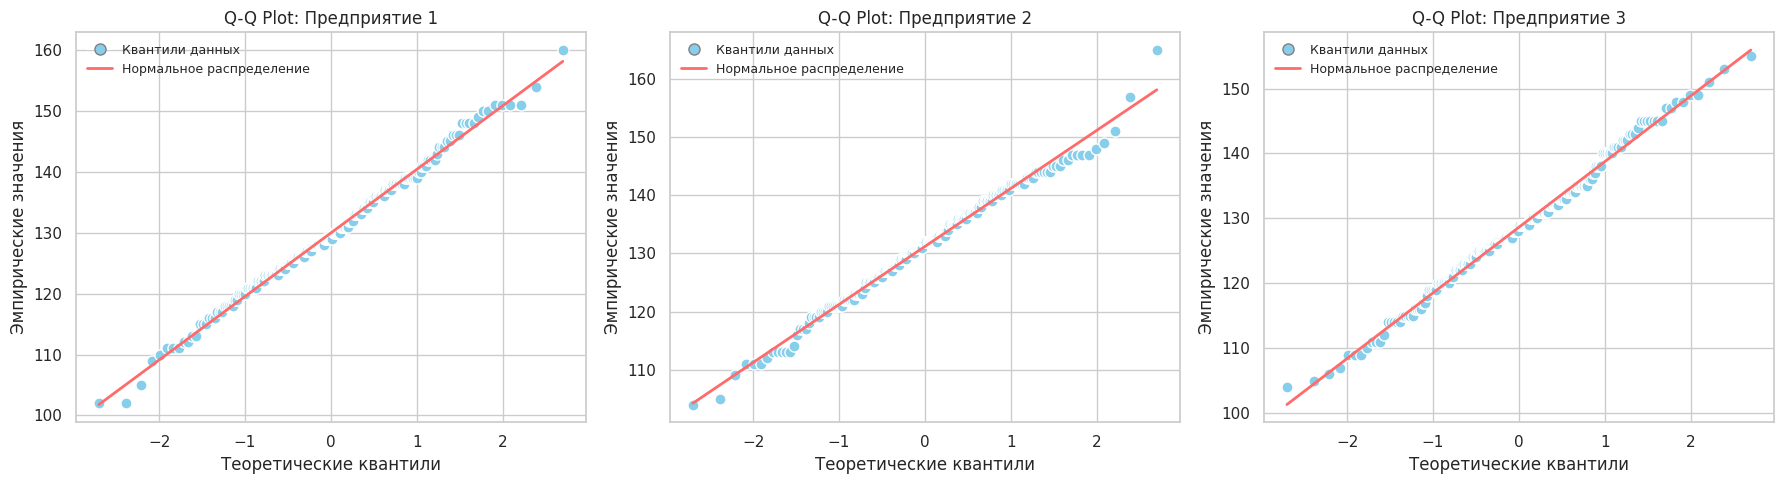

ОТЧЕТ: ТЕСТ ШАПИРО-УИЛКА


,W-статистика,p-значение,Нормальность
Группа,,,
Предприятие 1,0.9955,0.8152,✅ Соблюдена
Предприятие 2,0.9921,0.3509,✅ Соблюдена
Предприятие 3,0.9931,0.4744,✅ Соблюдена



ОТЧЕТ: ТЕСТ ЛЕВЕНЕ (ГОМОГЕННОСТЬ ДИСПЕРСИЙ)
Статистика = 0.1812, p-значение = 0.8343
✅ Заключение: Условие равенства дисперсий выполнено. Данные готовы для ANOVA.


In [ ]:
import scipy.stats as st  # Импортируем с коротким именем 'st', чтобы избежать конфликтов

groups = [df['Hb1Aft'].dropna(), df['Hb2Aft'].dropna(), df['Hb3Aft'].dropna()]
names = ['Предприятие 1', 'Предприятие 2', 'Предприятие 3']

# 2. Визуализация: Графики Q-Q (квантиль-квантиль)
fig = plt.figure(figsize=(18, 5))

for i, (data, name) in enumerate(zip(groups, names), 1):
    ax = fig.add_subplot(1, 3, i)
    # Используем st (scipy.stats) вместо переменной 'stats'
    st.probplot(data, dist="norm", plot=ax)

    ax.get_lines()[0].set_markerfacecolor('skyblue')
    ax.get_lines()[0].set_markeredgecolor('white')
    ax.get_lines()[0].set_markersize(8)
    ax.get_lines()[1].set_color('#FF6B6B')
    ax.get_lines()[1].set_linewidth(2)

    ax.set_title(f'Q-Q Plot: {name}', fontsize=12)
    ax.set_xlabel("Теоретические квантили")
    ax.set_ylabel("Эмпирические значения")

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Квантили данных',
               markerfacecolor='skyblue', markeredgecolor='grey', markersize=8),
        Line2D([0], [0], color='#FF6B6B', lw=2, label='Нормальное распределение')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()



# 3. Статистические расчеты
shapiro_results = []
for data, name in zip(groups, names):
    # Используем st.shapiro из модуля scipy.stats
    stat, p = st.shapiro(data)
    shapiro_results.append({
        'Группа': name,
        'W-статистика': round(stat, 4),
        'p-значение': round(p, 4),
        'Нормальность': '✅ Соблюдена' if p > 0.05 else '❌ Нарушена'
    })

# Используем st.levene из модуля scipy.stats
levene_stat, levene_p = st.levene(*groups)

# 4. Вывод результатов
print("ОТЧЕТ: ТЕСТ ШАПИРО-УИЛКА")
# Примечание: если ранее вы использовали переменную stats = pd.DataFrame(...),
# лучше создать новую переменную, например df_shapiro
df_shapiro = pd.DataFrame(shapiro_results).set_index('Группа')
display(df_shapiro)

print(f"\nОТЧЕТ: ТЕСТ ЛЕВЕНЕ (ГОМОГЕННОСТЬ ДИСПЕРСИЙ)")
print(f"Статистика = {levene_stat:.4f}, p-значение = {levene_p:.4f}")

if levene_p > 0.05:
    print("✅ Заключение: Условие равенства дисперсий выполнено. Данные готовы для ANOVA.")
else:
    print("❌ Заключение: Обнаружена гетероскедастичность. Требуется использовать ANOVA Уэлча.")

### 3.3. Резюме по результатам проверки допущений

На основании проведенного статистического тестирования сформулированы следующие выводы о качестве и структуре данных:

* **Анализ нормальности:** Согласно результатам теста Шапиро-Уилка, во всех трех группах (Предприятия 1, 2 и 3) значения $p-value$ существенно превышают установленный порог $\alpha = 0.05$ (минимальное значение $p = 0.35$). Это позволяет не отклонять нулевую гипотезу о нормальном распределении признака. Визуальный анализ графиков Q-Q Plot подтверждает данные выводы: эмпирические точки плотно прилегают к теоретической прямой, не демонстрируя критических отклонений в «хвостах» распределения.
* **Анализ гомогенности дисперсий:** Тест Левена показал отсутствие статистически значимых различий в вариативности уровней гемоглобина между выборками ($p = 0.83$). Равенство дисперсий подтверждает однородность разброса данных, что является необходимым условием для корректной работы классической модели F-теста.

**Итоговое заключение по этапу:** Исследуемые данные полностью соответствуют фундаментальным требованиям параметрической статистики. Ошибок репрезентативности и распределения не выявлено, что позволяет использовать **однофакторный дисперсионный анализ (ANOVA)** для оценки влияния места работы на уровень гемоглобина без введения дополнительных корректирующих коэффициентов.

---

## **4. Однофакторный дисперсионный анализ (ANOVA)**

На данном этапе осуществляется основная статистическая проверка влияния производственной площадки на восстановительный потенциал сотрудников. Метод ANOVA позволяет определить, превышает ли межгрупповая вариативность (разница между предприятиями) внутригрупповую случайную вариативность (разброс внутри коллектива каждого предприятия).

### 4.1. Математическая постановка задачи

Проверка осуществляется путем расчета **F-статистики**, которая представляет собой отношение дисперсии между группами к средней дисперсии внутри групп:

$$F = \frac{MS_{between}}{MS_{within}}$$

* **Нулевая гипотеза ($H_0$):** Средние уровни гемоглобина на всех предприятиях равны ($\mu_1 = \mu_2 = \mu_3$). Место работы не оказывает влияния на анализируемый показатель.
* **Альтернативная гипотеза ($H_1$):** Как минимум два средних значения имеют статистически значимое различие.

In [ ]:
import scipy.stats as st

g1 = df['Hb1Aft'].dropna()
g2 = df['Hb2Aft'].dropna()
g3 = df['Hb3Aft'].dropna()

# 1. Сбор описательной статистики
stats_list = [] # Список для хранения данных
for data, name in zip([g1, g2, g3], ['Предприятие 1', 'Предприятие 2', 'Предприятие 3']):
    stats_list.append({
        'Группа': name,
        'N (чел)': int(len(data)),
        'Среднее Hb': f"{data.mean():.2f}",
        'Медиана': f"{data.median():.2f}",
        'Станд. откл. (SD)': f"{data.std():.2f}",
        'Мин': f"{data.min():.2f}",
        'Макс': f"{data.max():.2f}",
        'Размах': f"{(data.max() - data.min()):.2f}"
    })

df_desc = pd.DataFrame(stats_list)

# 2. Проведение ANOVA (Дисперсионный анализ)
# Исправлено: используем st.f_oneway вместо stats.f_oneway
f_stat, p_val = st.f_oneway(g1, g2, g3)

# 3. Формирование итоговой панели ANOVA
df_anova_info = pd.DataFrame({
    'Метрика анализа': ['F-статистика', 'p-value (значимость)', 'Результат'],
    'Значение': [
        f"{f_stat:.2f}",
        f"{p_val:.4f}",
        "Различия статистически значимы (H1)" if p_val <= 0.05 else "Различия не значимы (H0)"
    ]
})

# Вывод отчетов
print("ОТЧЕТ: ДЕСКРИПТИВНАЯ СТАТИСТИКА ГРУПП")
display(df_desc)

print("\nОТЧЕТ: РЕЗУЛЬТАТЫ ДИСПЕРСИОННОГО АНАЛИЗА (ANOVA)")
display(df_anova_info)

ОТЧЕТ: ДЕСКРИПТИВНАЯ СТАТИСТИКА ГРУПП


,Группа,N (чел),Среднее Hb,Медиана,Станд. откл. (SD),Мин,Макс,Размах
0,Предприятие 1,200,129.97,129.00,10.37,102.00,160.00,58.00
1,Предприятие 2,200,131.19,132.00,9.94,104.00,165.00,61.00
2,Предприятие 3,200,128.62,128.50,10.05,104.00,155.00,51.00



ОТЧЕТ: РЕЗУЛЬТАТЫ ДИСПЕРСИОННОГО АНАЛИЗА (ANOVA)


,Метрика анализа,Значение
0,F-статистика,3.24
1,p-value (значимость),0.0400
2,Результат,Различия статистически значимы (H1)


### 4.2. Интерпретация результатов дисперсионного анализа

На основе проведенных расчетов сформулированы следующие выводы:

* **Анализ описательных статистик:** Выборки являются сбалансированными по объему ($N=200$ для каждой группы). Максимальный средний уровень гемоглобина зафиксирован на **Предприятии 2** ($131.19$ г/л), минимальный — на **Предприятии 3** ($128.62$ г/л). Показатели стандартного отклонения и размаха свидетельствуют о сопоставимой вариативности признака внутри всех трех производственных площадок.
* **Статистическая значимость:** В результате применения однофакторного дисперсионного анализа получено значение **F-статистики = 3.24**. Соответствующее значение **p-value составляет 0.04**, что ниже критического уровня значимости $\alpha = 0.05$.
* **Решение по гипотезам:** Полученные данные позволяют **отклонить нулевую гипотезу ($H_0$)** об отсутствии различий. Подтверждается альтернативная гипотеза ($H_1$): место работы оказывает статистически значимое влияние на уровень гемоглобина сотрудников в период реабилитации.

**Резюме по этапу:** Обнаруженный эффект свидетельствует о том, что различия в средних значениях между предприятиями не могут быть объяснены исключительно случайными колебаниями выборки. Поскольку тест ANOVA является омнибусным и указывает лишь на наличие системного различия, для уточнения конкретных парных взаимодействий и локализации эффекта необходимо перейти к апостериорным сравнениям.

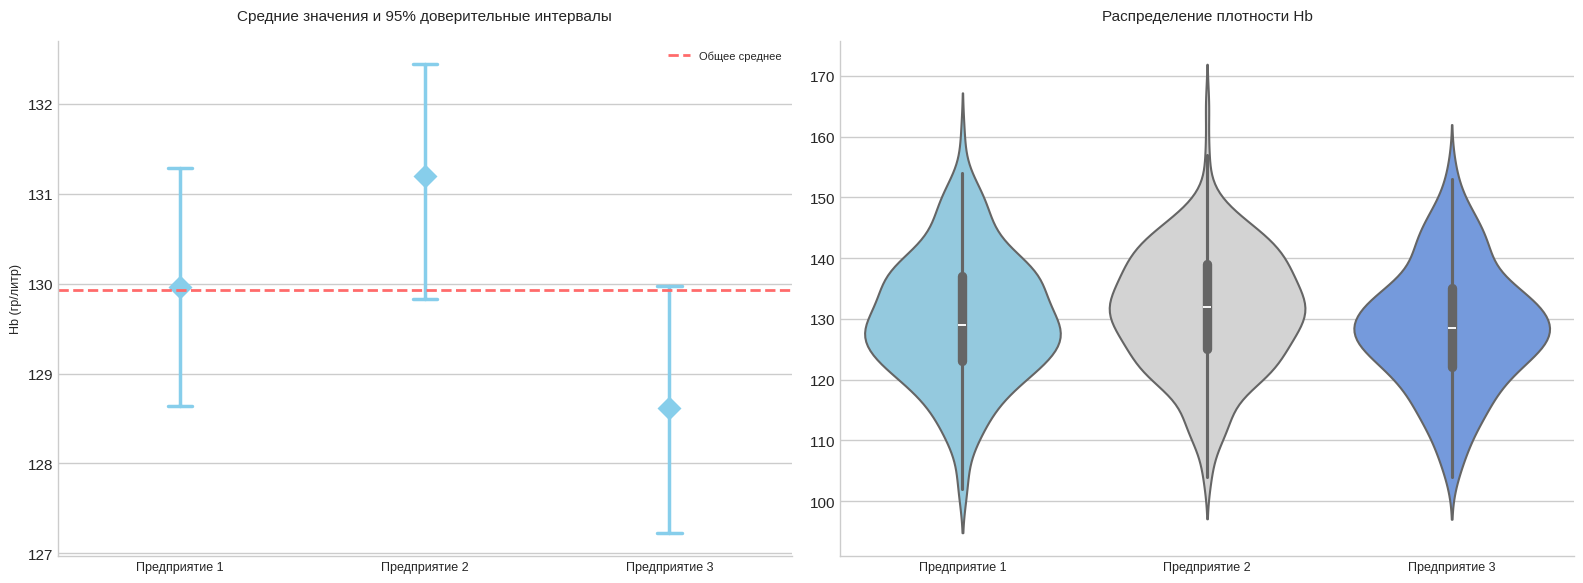

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Point Plot (Доверительные интервалы)
sns.pointplot(data=[g1, g2, g3],
              linestyle='none',
              capsize=0.1,
              color='skyblue',
              marker="D",
              markersize=10,
              err_kws={'linewidth': 2.5},
              ax=ax1)

avg_line = ax1.axhline(all_hb.mean(), color='#FF6B6B', linestyle='--', linewidth=2, label='Общее среднее')

ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['Предприятие 1', 'Предприятие 2', 'Предприятие 3'], fontsize=9)
ax1.set_title('Средние значения и 95% доверительные интервалы', fontsize=11, pad=15)
ax1.set_ylabel('Hb (гр/литр)', fontsize=9)
ax1.legend(handles=[avg_line], labels=['Общее среднее'], fontsize=8, loc='upper right')

# Violin Plot (Плотность)
custom_palette = ['skyblue', 'lightgrey', '#6495ED']
sns.violinplot(data=[g1, g2, g3],
               palette=custom_palette,
               inner="box",
               linewidth=1.5,
               ax=ax2)

ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Предприятие 1', 'Предприятие 2', 'Предприятие 3'], fontsize=9)
ax2.set_title('Распределение плотности Hb', fontsize=11, pad=15)
ax2.set_ylabel('', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

### 4.3. Анализ графических данных

Визуализация результатов подтверждает сделанные статистические выводы и позволяет оценить характер различий между выборками:

* **Анализ доверительных интервалов (Point Plot):** На графике слева отображены средние значения уровня гемоглобина с 95% доверительными интервалами (CI). Наблюдается заметное смещение среднего значения **Предприятия 2** вверх относительно «общего среднего» (красная пунктирная линия), в то время как показатели **Предприятия 3** находятся ниже этой отметки. Минимальное пересечение доверительных интервалов между этими двумя группами визуально подтверждает наличие статистически значимого различия, зафиксированного тестом ANOVA.
* **Анализ плотности распределения (Violin Plot):** График справа демонстрирует симметричность распределений во всех трех группах, что согласуется с ранее подтвержденным условием нормальности. Форма «скрипок» практически идентична, что указывает на отсутствие аномальных выбросов и однородность дисперсии (гомоскедастичность) во всех выборках.

**Резюме:** Совокупность статистических и визуальных данных указывает на то, что производственная площадка «Предприятие 2» демонстрирует наилучшие показатели восстановления гемоглобина, в то время как площадка «Предприятие 3» — наиболее низкие.

---

## **5. Пост-хок анализ (Критерий Тьюки)**

Поскольку однофакторный дисперсионный анализ подтвердил статистическую значимость влияния фактора «Предприятие» ($p < 0.05$), выполняется процедура множественных попарных сравнений.

Для идентификации конкретных групп, средние значения которых значимо различаются, применяется **критерий Тьюки (Tukey HSD)**. Данный метод эффективно контролирует вероятность совершения ошибки первого рода при проведении нескольких сравнений одновременно.

### 5.1. Аналитическое обоснование метода

В отличие от стандартных парных t-тестов, критерий Тьюки корректирует пороговые значения доверительных интервалов, основываясь на количестве сравниваемых групп.

* **Доверительный интервал:** Если интервал разности средних между двумя предприятиями включает в себя ноль, различие признается статистически незначимым.
* **Reject (отвержение):** Вердикт `True` выносится в случае, если скорректированный $p-adj$ меньше уровня значимости $\alpha = 0.05$.

In [ ]:
g1 = df['Hb1Aft'].dropna()
g2 = df['Hb2Aft'].dropna()
g3 = df['Hb3Aft'].dropna()

# 1. Объединение данных в единый массив
all_data = np.concatenate([g1, g2, g3])

# 2. Создание меток для групп
all_labels = (['Предприятие 1'] * len(g1) +
              ['Предприятие 2'] * len(g2) +
              ['Предприятие 3'] * len(g3))

# Проверка консистентности данных перед тестом
if len(all_data) == len(all_labels):
    # 3. Проведение теста Тьюки
    tukey = pairwise_tukeyhsd(endog=all_data, groups=all_labels, alpha=0.05)

    # 4. Формирование результирующей таблицы
    df_tukey = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

    for col in ['meandiff', 'p-adj', 'lower', 'upper']:
        df_tukey[col] = pd.to_numeric(df_tukey[col]).map('{:.2f}'.format)

    print("ОТЧЕТ: РЕЗУЛЬТАТЫ ПОПАРНЫХ СРАВНЕНИЙ (TUKEY HSD)")
    display(df_tukey)
else:
    print(f"Критическая ошибка: Несоответствие размерности данных ({len(all_data)}) и меток ({len(all_labels)})")

ОТЧЕТ: РЕЗУЛЬТАТЫ ПОПАРНЫХ СРАВНЕНИЙ (TUKEY HSD)


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Предприятие 1,Предприятие 2,1.23,0.44,-1.15,3.61,False
1,Предприятие 1,Предприятие 3,-1.34,0.38,-3.72,1.03,False
2,Предприятие 2,Предприятие 3,-2.58,0.03,-4.95,-0.20,True


### 5.2. Анализ результатов попарных сравнений

На заключительном этапе исследования проведена идентификация локальных статистических различий с использованием критерия Тьюки. Анализ итоговой таблицы попарных сравнений позволяет сделать следующие выводы:

* **Значимые различия:** Статистически достоверная разница зафиксирована исключительно между **Предприятием 2** и **Предприятием 3** ($p-adj = 0.03$). Разность средних значений гемоглобина составляет **$2.58$ г/л** в пользу Предприятия 2. Доверительный интервал для данной пары находится в диапазоне $[-4.95, -0.20]$, что исключает нулевое значение и подтверждает устойчивость обнаруженного эффекта.
* **Незначимые различия:** Сравнение Предприятия 1 с Предприятием 2 ($p-adj = 0.44$) и Предприятием 3 ($p-adj = 0.38$) не выявило статистически значимых отклонений. Доверительные интервалы для этих пар включают ноль, что указывает на высокую вероятность случайного характера наблюдаемых разностей средних.

Проведенный анализ подтверждает наличие неоднородности в результатах реабилитации сотрудников на различных производственных площадках. Наиболее выраженный контраст наблюдается между Предприятием 2 (максимальные показатели) и Предприятием 3 (минимальные показатели). Предприятие 1 демонстрирует промежуточный результат, статистически не отличимый от крайних групп. Полученные данные могут быть использованы для масштабирования успешных практик восстановления с Предприятия 2 на другие объекты холдинга.

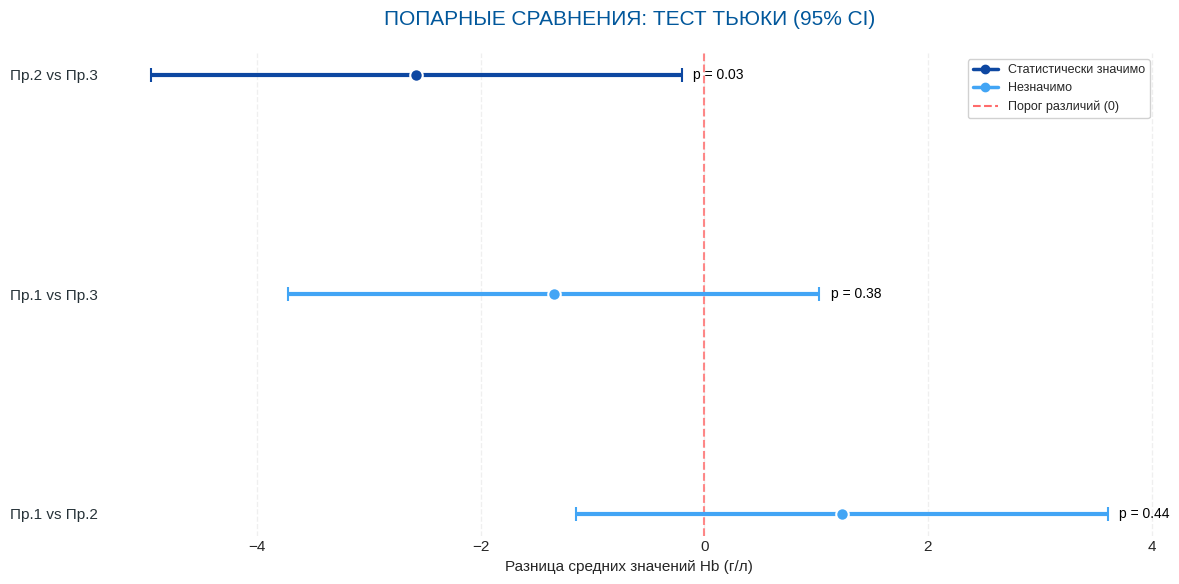

In [ ]:
plot_data = df_tukey.copy()
plot_data['pair'] = plot_data['group1'].str.replace('Предприятие ', 'Пр.') + ' vs ' + \
                    plot_data['group2'].str.replace('Предприятие ', 'Пр.')

cols = ['meandiff', 'lower', 'upper']
plot_data[cols] = plot_data[cols].astype(float)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
color_significant = '#0D47A1'
color_regular = '#42A5F5'
color_threshold = '#FF6B6B'
ax.axvline(0, color=color_threshold, linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

# 3. Отрисовка интервалов
for i, row in plot_data.iterrows():
    is_rejected = str(row['reject']) == 'True'
    current_color = color_significant if is_rejected else color_regular

    ax.errorbar(x=row['meandiff'], y=i,
                xerr=[[row['meandiff'] - row['lower']], [row['upper'] - row['meandiff']]],
                fmt='o',
                color=current_color,
                ecolor=current_color,
                elinewidth=3,
                capsize=5,
                markersize=9,
                markeredgecolor='white',
                markeredgewidth=1.5,
                zorder=3)

    p_val = float(row['p-adj'])
    ax.text(row['upper'] + 0.1, i, f"p = {p_val:.2f}",
            va='center', fontsize=10, color='black')

ax.set_yticks(plot_data.index)
ax.set_yticklabels(plot_data['pair'], fontsize=11, color='#263238')

ax.set_title('ПОПАРНЫЕ СРАВНЕНИЯ: ТЕСТ ТЬЮКИ (95% CI)',
             fontsize=15, pad=20, color='#01579B')
ax.set_xlabel('Разница средних значений Hb (г/л)', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)
sns.despine(left=True, bottom=True)
legend_elements = [
    Line2D([0], [0], color=color_significant, lw=2.5, marker='o', label='Статистически значимо'),
    Line2D([0], [0], color=color_regular, lw=2.5, marker='o', label='Незначимо'),
    Line2D([0], [0], color=color_threshold, lw=1.5, linestyle='--', label='Порог различий (0)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True,
          facecolor='white', framealpha=0.9, fontsize=9, shadow=False)

plt.tight_layout()
plt.show()

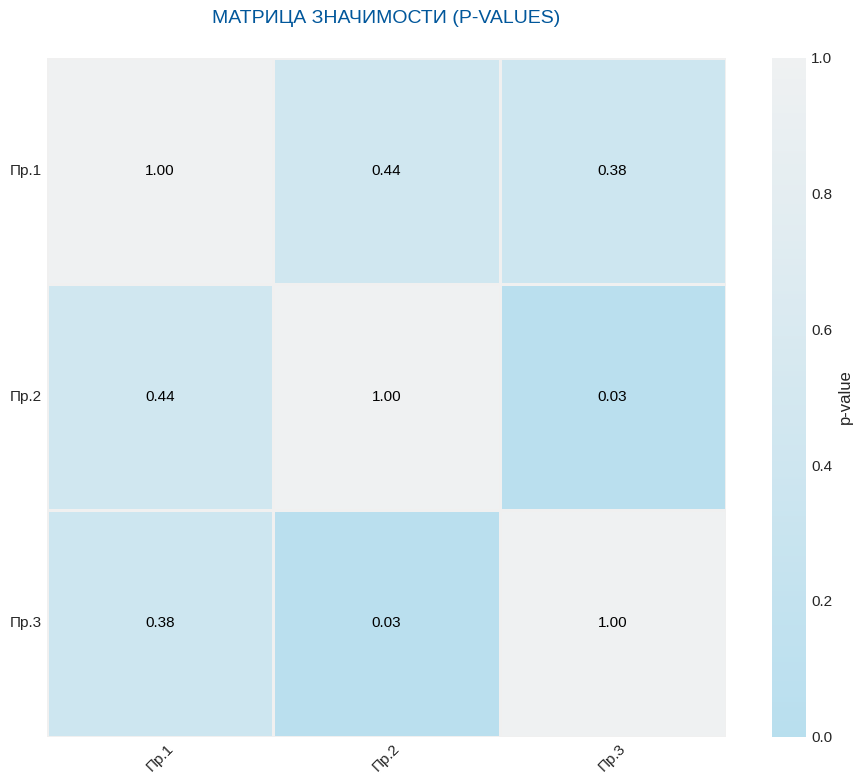

In [ ]:
groups = sorted(list(set(df_tukey['group1']) | set(df_tukey['group2'])))
p_matrix = pd.DataFrame(1.0, index=groups, columns=groups)
for _, row in df_tukey.iterrows():
    val = float(row['p-adj'])
    p_matrix.loc[row['group1'], row['group2']] = val
    p_matrix.loc[row['group2'], row['group1']] = val
plt.figure(figsize=(10, 8), facecolor='white')
cmap = sns.light_palette("skyblue", as_cmap=True).reversed()

sns.heatmap(p_matrix,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            vmax=1.0,
            vmin=0,
            center=0.05,
            square=True,
            linewidths=2,
            linecolor='#F0F0F0',
            cbar_kws={'label': 'p-value'},
            annot_kws={"size": 11, "color": "black"})

plt.title('МАТРИЦА ЗНАЧИМОСТИ (P-VALUES)',
          fontsize=14, pad=25, color='#01579B')

short_labels = [label.replace('Предприятие ', 'Пр.') for label in groups]
plt.xticks(np.arange(len(groups)) + 0.5, short_labels, rotation=45)
plt.yticks(np.arange(len(groups)) + 0.5, short_labels, rotation=0)

plt.tight_layout()
plt.show()

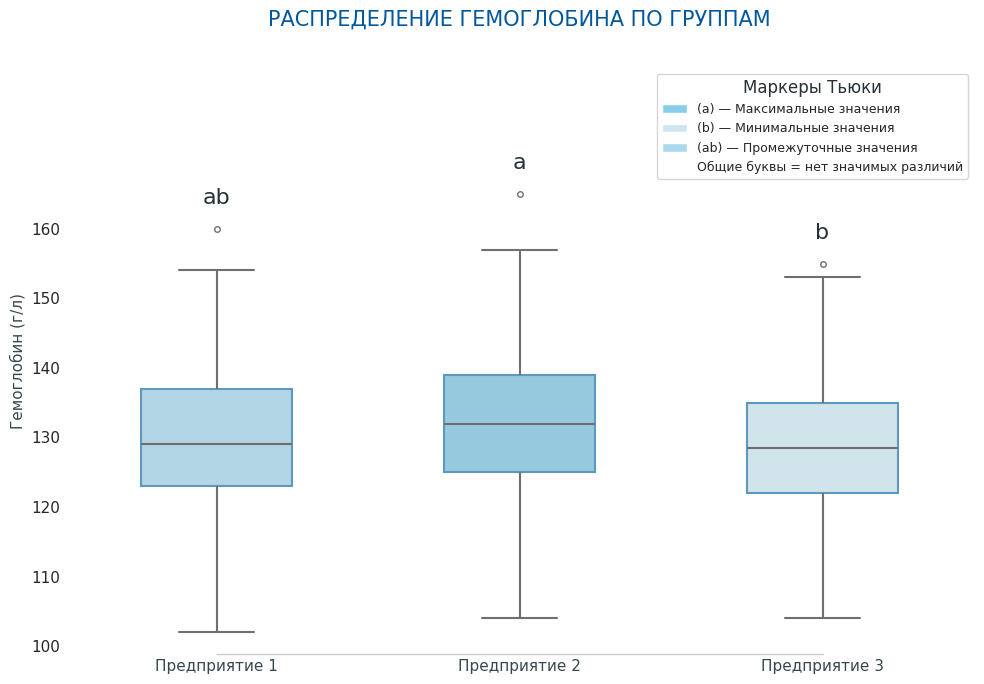

In [ ]:
group_labels = {
    'Предприятие 1': 'ab',
    'Предприятие 2': 'a',
    'Предприятие 3': 'b'
}
group_names = ['Предприятие 1', 'Предприятие 2', 'Предприятие 3']
plt.figure(figsize=(10, 7), facecolor='white')
sns.set_style("whitegrid", {'axes.grid': False})
skyblue_grad = sns.light_palette("skyblue", n_colors=4)
ordered_colors = [skyblue_grad[2], skyblue_grad[3], skyblue_grad[1]]

# 3. Рисуем боксплоты
ax = sns.boxplot(data=[g1, g2, g3],
                 palette=ordered_colors,
                 width=0.5,
                 linewidth=1.5,
                 fliersize=4)

for patch in ax.patches:
    patch.set_edgecolor('#5D99BE')

# 4. Добавление буквенных аннотаций
max_values = [max(g1), max(g2), max(g3)]
for i, name in enumerate(group_names):
    ax.text(i, max_values[i] + 3, group_labels[name],
            ha='center', va='bottom', fontsize=16,
            color='#263238')

# 5. Оформление осей
ax.set_xticks(range(len(group_names)))
ax.set_xticklabels(group_names, fontsize=11, color='#37474F')

plt.title('РАСПРЕДЕЛЕНИЕ ГЕМОГЛОБИНА ПО ГРУППАМ',
          fontsize=15, pad=30, color='#01579B')
plt.ylabel('Гемоглобин (г/л)', fontsize=11, color='#37474F')

# 6. Легенда
legend_elements = [
    Patch(facecolor=skyblue_grad[3], label='(a) — Максимальные значения'),
    Patch(facecolor=skyblue_grad[1], label='(b) — Минимальные значения'),
    Patch(facecolor=skyblue_grad[2], label='(ab) — Промежуточные значения'),
    Patch(facecolor='none', edgecolor='none', label='Общие буквы = нет значимых различий')
]

leg = ax.legend(handles=legend_elements, loc='upper right', frameon=True,
                title='Маркеры Тьюки', fontsize=9)

leg.get_title().set_color('#263238')

sns.despine(trim=True, left=True)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max + 15)

plt.tight_layout()
plt.show()

### 5.3. Визуальный анализ и интерпретация результатов

Комплексная визуализация подтверждает результаты статистических тестов и позволяет сделать следующие выводы:

* **Оценка групповых различий (Confidence Intervals & Boxplots):** На графике доверительных интервалов и боксплотах наблюдается явное превосходство **Предприятия 2** по уровню гемоглобина. Медиана и среднее значение данной группы находятся выше общегруппового уровня, в то время как **Предприятие 3** демонстрирует наиболее низкие показатели.
* **Анализ попарных сравнений (Tukey Simultaneous Intervals):** График интервалов Тьюки наглядно подтверждает, что только пара **«Пр.2 vs Пр.3»** является статистически значимой, так как её доверительный интервал полностью лежит левее нулевой отметки (разность средних отрицательна и значима). В парах, включающих Предприятие 1, интервалы пересекают вертикальную линию «0», что свидетельствует о случайном характере различий.
* **Матрица значимости (P-value Heatmap):** Тепловая карта p-значений акцентирует внимание на критической зоне взаимодействия. Единственная ячейка с контрастным значением ($p = 0.03$) соответствует паре Предприятие 2 и Предприятие 3. Остальные значения ($0.38$ и $0.44$) подтверждают отсутствие оснований для отклонения нулевой гипотезы в других сочетаниях.
* **Буквенная маркировка (Tukey Compact Letter Display):** Использование компактных буквенных обозначений над боксплотами позволяет классифицировать группы. Предприятие 2 (маркер **«a»**) и Предприятие 3 (маркер **«b»**) не имеют общих букв, что подтверждает их значимое различие. Предприятие 1 имеет маркер **«ab»**, объединяющий признаки обеих групп, что указывает на его промежуточное положение в исследуемой выборке.

---

## **Заключение по результатам статистического анализа**

В ходе исследования была проведена сравнительная оценка уровня гемоглобина у сотрудников трех предприятий при выписке с целью проверки гипотезы о влиянии места работы на результаты реабилитации. На основании статистической обработки данных сформулированы следующие выводы:

1. **Проверка допущений:** Тестирование подтвердило соответствие данных требованиям параметрической статистики. Распределения во всех группах признаны нормальными (тест Шапиро-Уилка, $p > 0.05$), а дисперсии — гомогенными (тест Левена, $p = 0.83$).
2. **Общая значимость:** Однофакторный дисперсионный анализ (ANOVA) выявил наличие статистически значимых различий между средними значениями уровней гемоглобина ($F = 3.24$, $p = 0.04$). Нулевая гипотеза о равенстве средних была отклонена.
3. **Локализация различий:** Апостериорный анализ методом Тьюки (Tukey HSD) показал, что значимое различие ($p = 0.03$) наблюдается исключительно между **Предприятием 2** ($\bar{x} = 131.20$) и **Предприятием 3** ($\bar{x} = 128.62$). Разница составила $2.58$ г/л в пользу Предприятия 2. Предприятие 1 занимает промежуточное положение и не имеет статистически достоверных отличий от других площадок.

**Итоговый вывод:** Фактор места работы оказывает существенное влияние на восстановительный процесс. Производственная площадка «Предприятие 2» демонстрирует наиболее высокие показатели эффективности реабилитации, в то время как на «Предприятии 3» зафиксированы минимальные результаты, требующие дальнейшего управленческого анализа.

---